Satisfaction TriBagas Nurkholis
Mini Project

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('Customer Satisfaction and Sentiment Analysis.csv')
df_clean = df.copy()

Data Understanding & Preparation

In [6]:
#Melihat informasi ata 5 teratas
df_clean.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [10]:
#Melihat tipe data dan jumlah data yang kosong
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         100000 non-null  int64  
 1   id                                 100000 non-null  int64  
 2   Gender                             100000 non-null  object 
 3   Customer Type                      100000 non-null  object 
 4   Age                                100000 non-null  int64  
 5   Type of Travel                     100000 non-null  object 
 6   Class                              100000 non-null  object 
 7   Flight Distance                    100000 non-null  int64  
 8   Inflight wifi service              100000 non-null  int64  
 9   Departure/Arrival time convenient  100000 non-null  int64  
 10  Ease of Online booking             100000 non-null  int64  
 11  Gate location                      10000

In [11]:
#Melihat statistik deskriptif dari data numerik
df_clean.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.00000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,99700.000000
mean,49999.500000,64925.805660,39.379330,1190.58611,2.728820,3.059130,2.75604,2.97566,3.203310,3.250760,3.440340,3.358180,3.382230,3.350560,3.631930,3.303820,3.64012,3.287260,14.823680,15.185727
std,28867.657797,37453.371794,15.110524,997.24029,1.327411,1.525273,1.39810,1.27692,1.329779,1.349273,1.319325,1.333403,1.288707,1.315464,1.180749,1.265286,1.17590,1.312158,38.206983,38.677722
min,0.000000,1.000000,7.000000,31.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,24999.750000,32554.750000,27.000000,414.00000,2.000000,2.000000,2.00000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.00000,2.000000,0.000000,0.000000
50%,49999.500000,64883.500000,40.000000,844.00000,3.000000,3.000000,3.00000,3.00000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.00000,3.000000,0.000000,0.000000
75%,74999.250000,97346.250000,51.000000,1744.00000,4.000000,4.000000,4.00000,4.00000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.00000,4.000000,12.000000,13.000000
max,99999.000000,129880.000000,85.000000,4983.00000,5.000000,5.000000,5.00000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,1592.000000,1584.000000


In [14]:
#Melihat statistik deskriptif dari data kategorikal
df.describe(include='object')

,Gender,Customer Type,Type of Travel,Class,satisfaction
count,100000,100000,100000,100000,100000
unique,2,2,2,3,2
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,50714,81713,68977,47806,56665


In [12]:
df_clean.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             300
satisfaction    

In [13]:
df_clean.duplicated().sum()

np.int64(0)

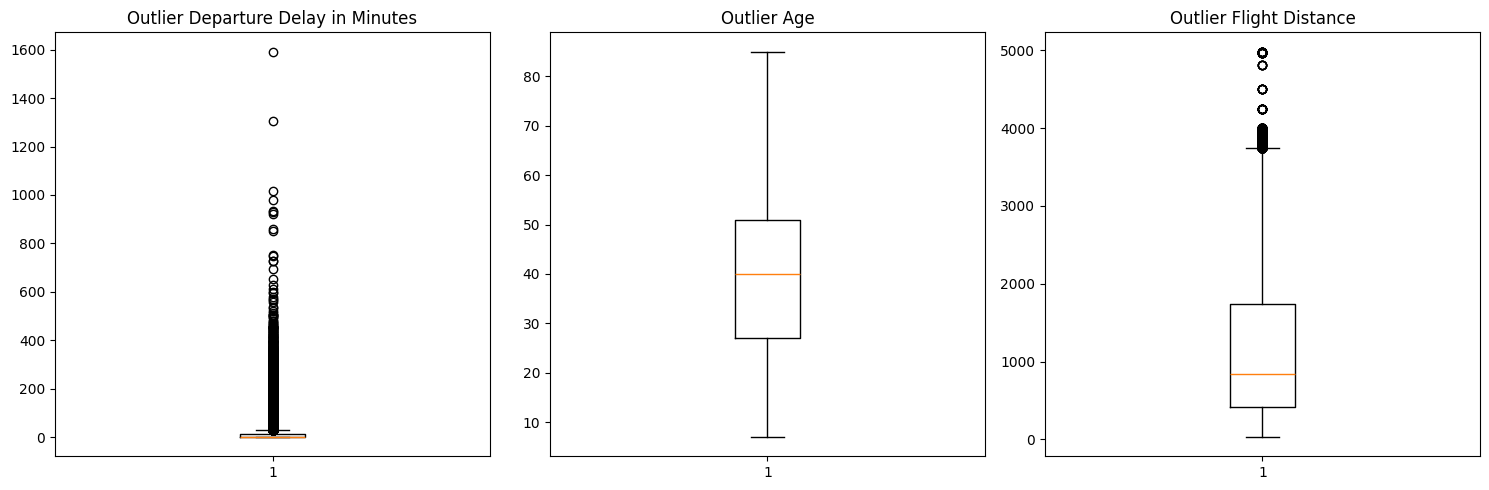

In [19]:
kolom = ['Departure Delay in Minutes','Age', 'Flight Distance',]
plt.figure(figsize=(15,5))

for i, col in enumerate(kolom, 1):

    plt.subplot(1, 3, i)
    plt.boxplot(df[col])
    plt.title(f"Outlier {col}")
    
plt.tight_layout()
plt.show()

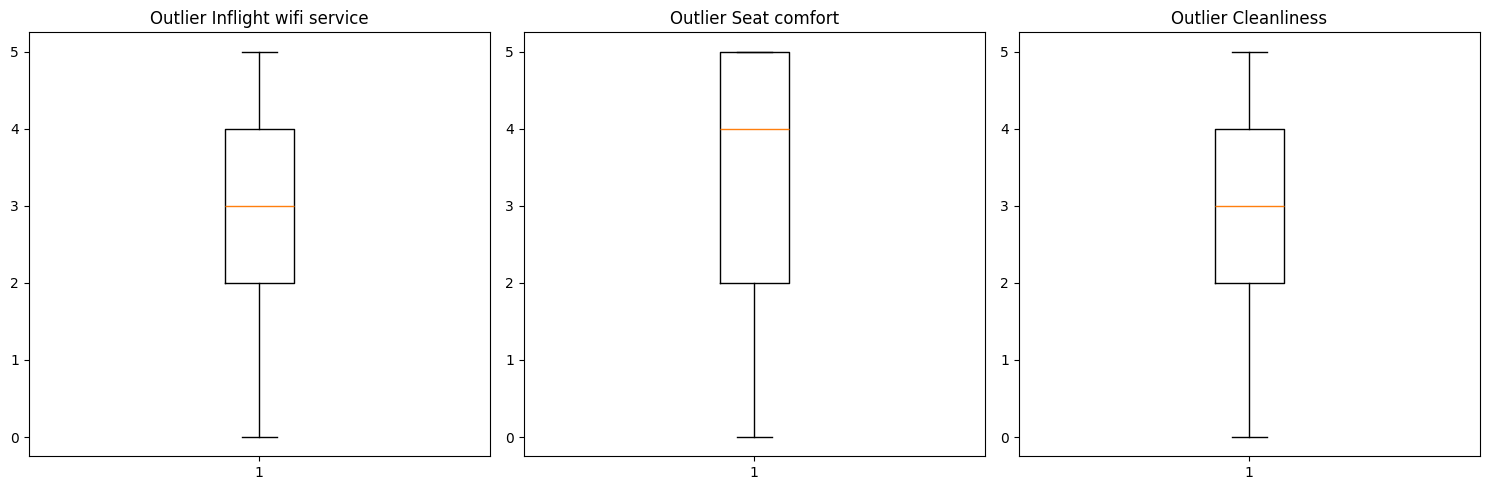

In [20]:
kolom = ['Inflight wifi service','Seat comfort', 'Cleanliness']
plt.figure(figsize=(15,5))

for i, col in enumerate(kolom, 1):

    plt.subplot(1, 3, i)
    plt.boxplot(df[col])
    plt.title(f"Outlier {col}")
    
plt.tight_layout()
plt.show()

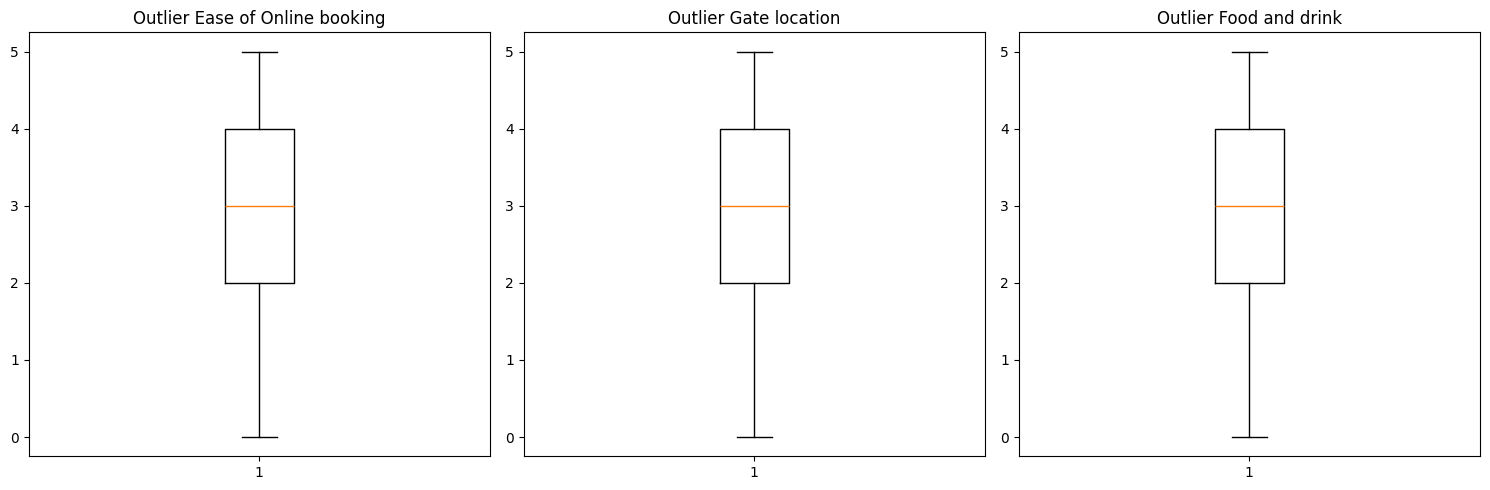

In [ ]:
kolom = ['Ease of Online booking','Gate location', 'Food and drink']
plt.figure(figsize=(15,5))

for i, col in enumerate(kolom, 1):

    plt.subplot(1, 3, i)
    plt.boxplot(df[col])
    plt.title(f"Outlier {col}")
    
plt.tight_layout()
plt.show()

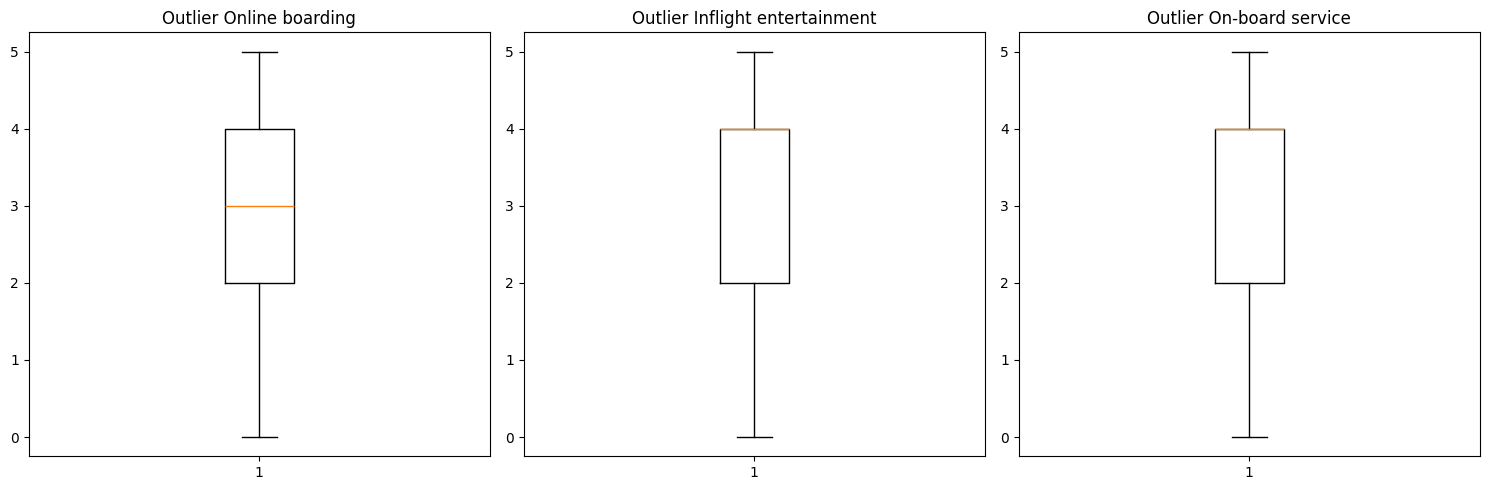

In [ ]:
kolom = ['Online boarding','Inflight entertainment', 'On-board service']
plt.figure(figsize=(15,5))

for i, col in enumerate(kolom, 1):

    plt.subplot(1, 3, i)
    plt.boxplot(df[col])
    plt.title(f"Outlier {col}")
    
plt.tight_layout()
plt.show()

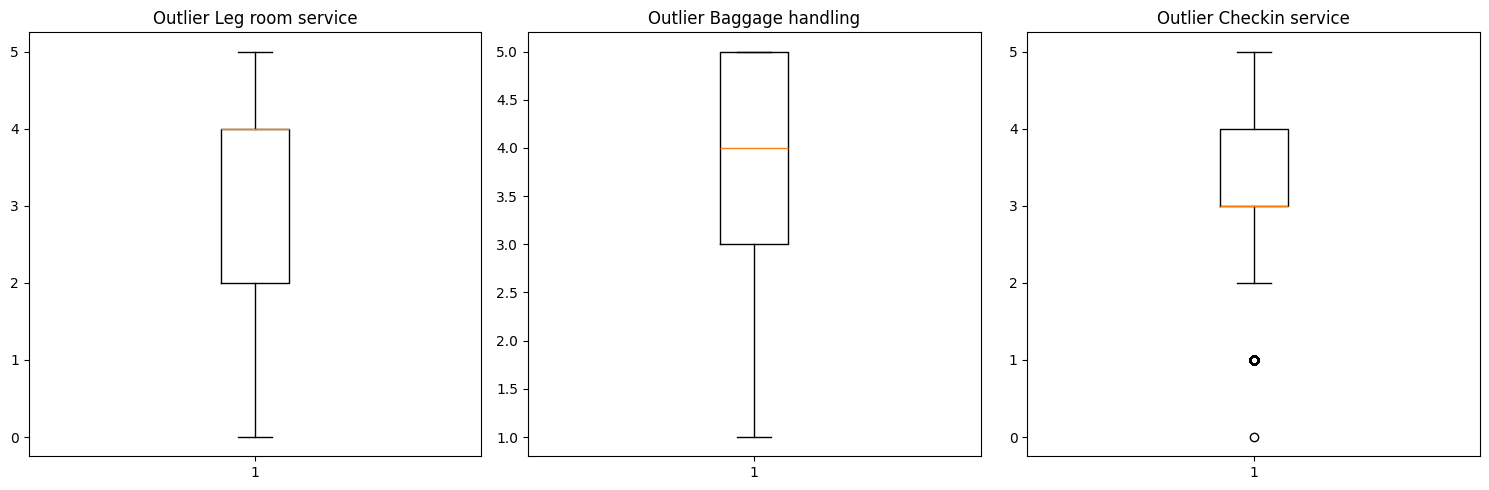

In [ ]:
kolom = ['Leg room service','Baggage handling', 'Checkin service']
plt.figure(figsize=(15,5))

for i, col in enumerate(kolom, 1):

    plt.subplot(1, 3, i)
    plt.boxplot(df[col])
    plt.title(f"Outlier {col}")
    
plt.tight_layout()
plt.show()

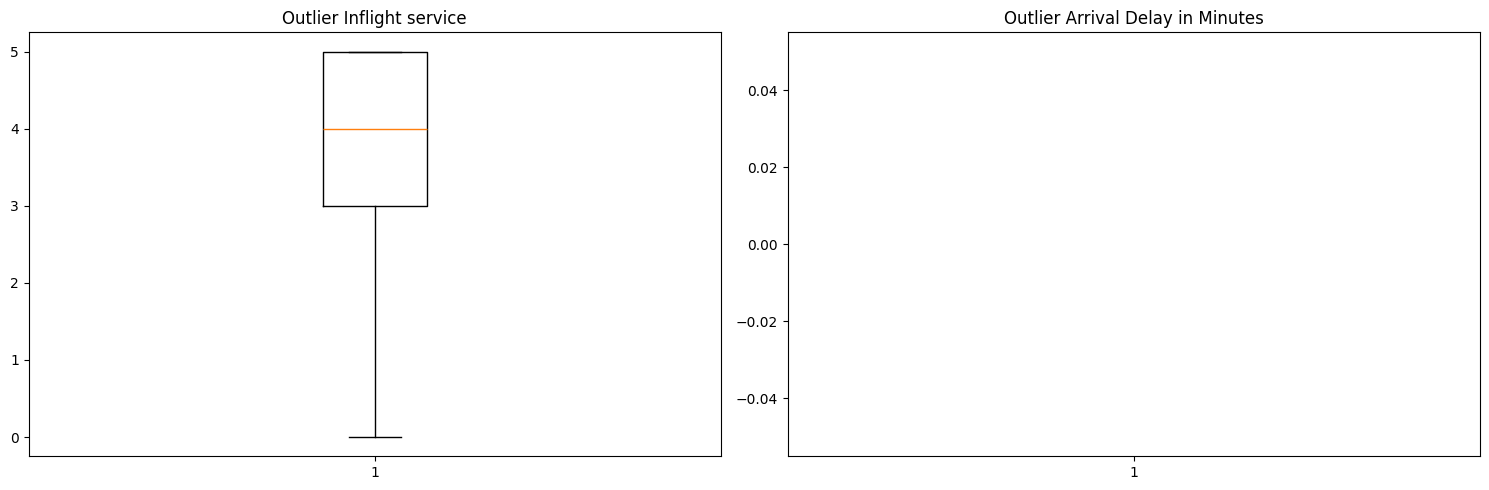

In [34]:
kolom = ['Inflight service','Arrival Delay in Minutes']
plt.figure(figsize=(15,5))

for i, col in enumerate(kolom, 1):

    plt.subplot(1, 2, i)
    plt.boxplot(df[col])
    plt.title(f"Outlier {col}")
    
plt.tight_layout()
plt.show()

In [30]:
Q1 = df_clean['Flight Distance'].quantile(0.25)
Q3 = df_clean['Flight Distance'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_FlightDistance = (
    (df_clean['Flight Distance'] < lower_bound) |
    (df_clean['Flight Distance'] > upper_bound)
)

jumlah_outlier = outlier_FlightDistance.sum()
total_data = len(df_clean)
persentase_outlier = (jumlah_outlier / total_data) * 100

print(f"Jumlah outlier Flight Distance: {jumlah_outlier}")
print(f"Total data: {total_data}")
print(f"Persentase outlier: {persentase_outlier:.2f}%")

Jumlah outlier Flight Distance: 2185
Total data: 100000
Persentase outlier: 2.19%


In [35]:
Q1 = df_clean['Age'].quantile(0.25)
Q3 = df_clean['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_Age = (
    (df_clean['Age'] < lower_bound) |
    (df_clean['Age'] > upper_bound)
)

jumlah_outlier = outlier_Age.sum()
total_data = len(df_clean)
persentase_outlier = (jumlah_outlier / total_data) * 100

print(f"Jumlah outlier Age: {jumlah_outlier}")
print(f"Total data: {total_data}")
print(f"Persentase outlier: {persentase_outlier:.2f}%")

Jumlah outlier Age: 0
Total data: 100000
Persentase outlier: 0.00%


In [31]:
Q1 = df_clean['Departure Delay in Minutes'].quantile(0.25)
Q3 = df_clean['Departure Delay in Minutes'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_DepartureDelayInMinutes = (
    (df_clean['Departure Delay in Minutes'] < lower_bound) |
    (df_clean['Departure Delay in Minutes'] > upper_bound)
)

jumlah_outlier = outlier_DepartureDelayInMinutes.sum()
total_data = len(df_clean)
persentase_outlier = (jumlah_outlier / total_data) * 100

print(f"Jumlah outlier Departure Delay in Minutes: {jumlah_outlier}")
print(f"Total data: {total_data}")
print(f"Persentase outlier: {persentase_outlier:.2f}%")

Jumlah outlier Departure Delay in Minutes: 14019
Total data: 100000
Persentase outlier: 14.02%


In [32]:
Q1 = df_clean['Arrival Delay in Minutes'].quantile(0.25)
Q3 = df_clean['Arrival Delay in Minutes'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_ArrivalDelayInMinutes = (
    (df_clean['Arrival Delay in Minutes'] < lower_bound) |
    (df_clean['Arrival Delay in Minutes'] > upper_bound)
)

jumlah_outlier = outlier_ArrivalDelayInMinutes.sum()
total_data = len(df_clean)
persentase_outlier = (jumlah_outlier / total_data) * 100

print(f"Jumlah outlier Arrival Delay in Minutes: {jumlah_outlier}")
print(f"Total data: {total_data}")
print(f"Persentase outlier: {persentase_outlier:.2f}%")

Jumlah outlier Arrival Delay in Minutes: 13470
Total data: 100000
Persentase outlier: 13.47%


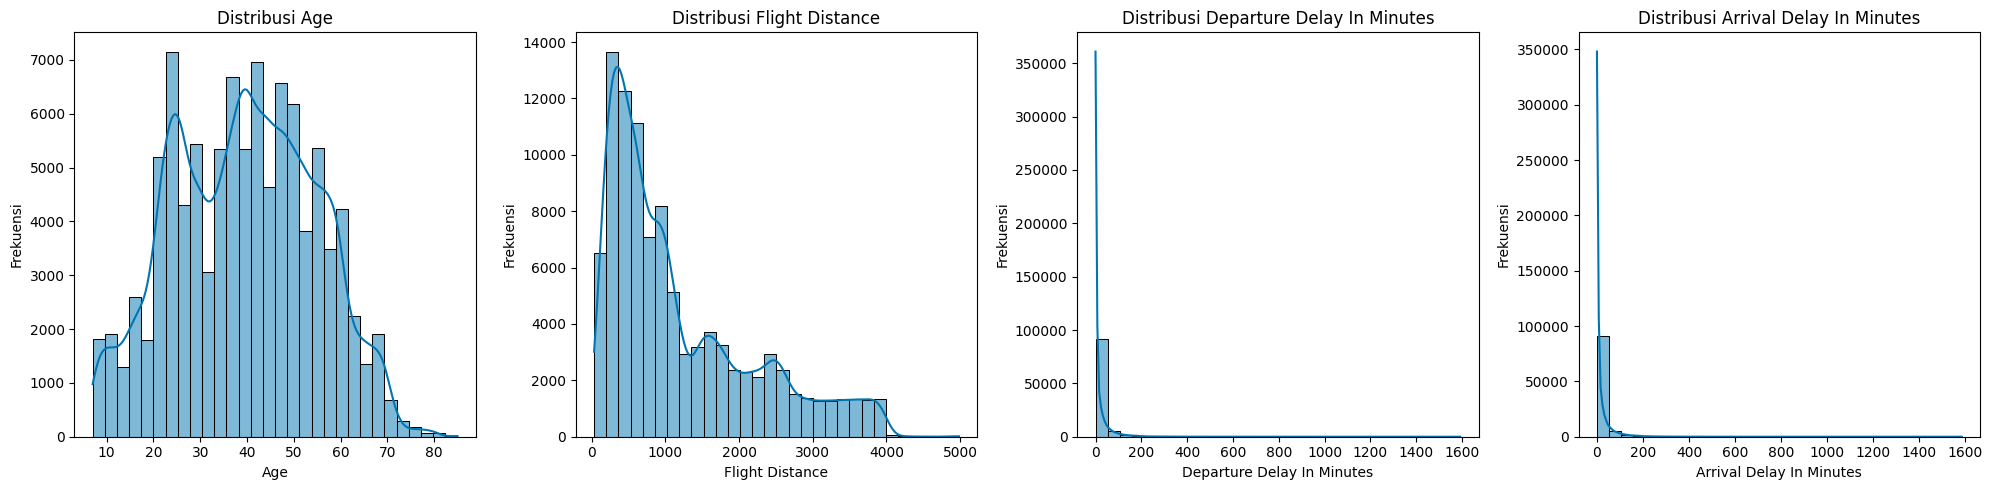

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Kolom numerik yang akan dicek
kolom_numerik = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]

# Mengatur tampilan grid grafik
fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # Mengubah jumlah subplot menjadi 4

for i, col in enumerate(kolom_numerik):
    # Membuat format penulisan judul menjadi Proper Case
    col_title = col.replace('_', ' ').title()
    
    # Plot histogram dengan kurva kepadatan (KDE)
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color="#0075b2", bins=30)
    axes[i].set_title(f'Distribusi {col_title}')
    axes[i].set_xlabel(col_title)
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

In [40]:
df_clean['Gender'] = df_clean['Gender'].str.strip().str.lower()
df_clean['Customer Type'] = df_clean['Customer Type'].str.strip().str.lower()
df_clean['Type of Travel'] = df_clean['Type of Travel'].str.strip().str.lower()
df_clean['Class'] = df_clean['Class'].str.strip().str.lower()
df_clean['satisfaction'] = df_clean['satisfaction'].str.strip().str.lower()
df_clean.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,male,loyal customer,13,personal travel,eco plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,male,disloyal customer,25,business travel,business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,female,loyal customer,26,business travel,business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,female,loyal customer,25,business travel,business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,male,loyal customer,61,business travel,business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [43]:
df_clean = df.drop(columns=['Unnamed: 0'])
df_clean.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [45]:
from scipy.stats import shapiro

numeric_cols = [
    'Age',
    'Flight Distance',
    'Departure Delay in Minutes',
    'Arrival Delay in Minutes'
]

for col in numeric_cols:

    stat, p = shapiro(df[col].dropna().sample(5000, random_state=42))

    print(f"\nKolom: {col}")
    print("Statistic:", stat)
    print("P-value:", p)
    if p > 0.05:
        print("Distribusi Normal")
    else:
        print("Distribusi Tidak Normal")


Kolom: Age
Statistic: 0.9885256671138158
P-value: 9.58388034354491e-20
Distribusi Tidak Normal

Kolom: Flight Distance
Statistic: 0.8618262104705304
P-value: 8.31627682059917e-55
Distribusi Tidak Normal

Kolom: Departure Delay in Minutes
Statistic: 0.43896194294852253
P-value: 1.1672484239836355e-82
Distribusi Tidak Normal

Kolom: Arrival Delay in Minutes
Statistic: 0.46641478617398346
P-value: 1.4635376963009756e-81
Distribusi Tidak Normal


In [49]:
df_clean['satisfaction_num'] = df_clean['satisfaction'].map({
    'neutral or dissatisfied': 0,
    'satisfied': 1
})

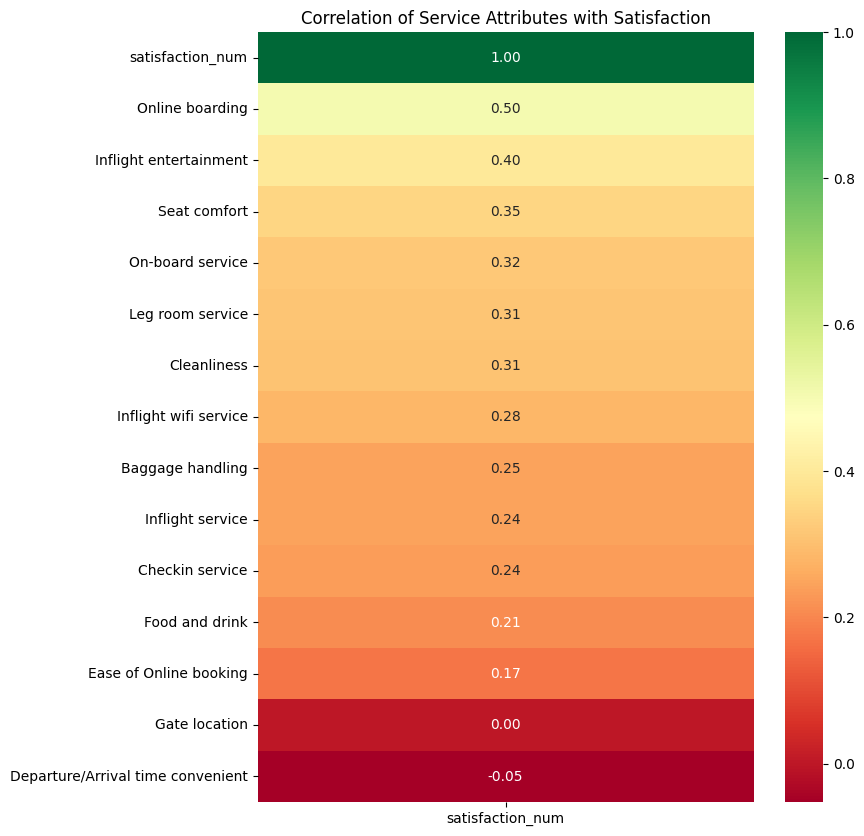

In [55]:
service_cols = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

import seaborn as sns
import matplotlib.pyplot as plt

corr_target = df[
    service_cols + ['satisfaction_num']
].corr()[['satisfaction_num']]

plt.figure(figsize=(8,10))

sns.heatmap(
    corr_target.sort_values(
        by='satisfaction_num',
        ascending=False
    ),
    annot=True,
    cmap='RdYlGn',
    fmt='.2f'
)

plt.title('Correlation of Service Attributes with Satisfaction')

plt.show()

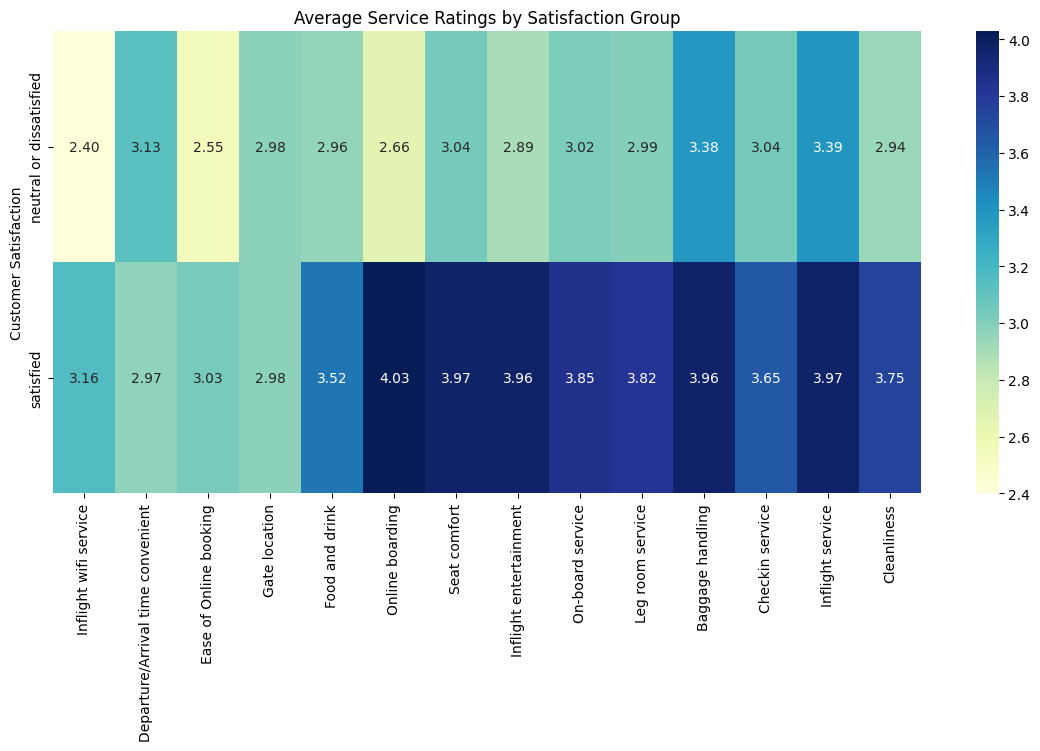

In [56]:
service_heatmap = df.groupby(
    'satisfaction'
)[service_cols].mean()

plt.figure(figsize=(14,6))

sns.heatmap(
    service_heatmap,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f'
)

plt.title(
    'Average Service Ratings by Satisfaction Group'
)

plt.ylabel('Customer Satisfaction')

plt.show()

In [57]:
df_clean.to_csv('Customer Satisfaction and Setiment Analysis_clean.csv', index=False)